In [6]:
import os

# Change to your project directory (update the path as needed)
os.chdir(r"G:\Snow-Analyze-in-Iran")

# Verify the change
print(os.getcwd())

G:\Snow-Analyze-in-Iran


In [7]:
# ============================================================
# Snow Climatology, Trends, and Snow Drought Assessment in Iran
# Period: 1950–2023
# Author: Ali Rezaee
#
# Purpose
# -------
# This notebook provides a reproducible workflow for analyzing
# snow-related variables over Iran, including climatology,
# snow drought assessment, trend analysis, and early snowmelt
# indicators.
#
# The code is written to support a scientific manuscript and
# to be shared as documented supplementary material.
# ============================================================


# ------------------------------
# 1. Standard library imports
# ------------------------------

from pathlib import Path
import os
import warnings
import json
from typing import Dict, List, Optional, Tuple


# ------------------------------
# 2. Scientific Python imports
# ------------------------------

import numpy as np
import pandas as pd
import xarray as xr


# ------------------------------
# 3. Geospatial imports
# ------------------------------

import geopandas as gpd
import rioxarray
import rasterio
from shapely.geometry import mapping


# ------------------------------
# 4. Statistical imports
# ------------------------------

from scipy import stats
from scipy.stats import linregress

try:
    import pymannkendall as mk
    HAS_PYMANNKENDALL = True
except ImportError:
    HAS_PYMANNKENDALL = False
    warnings.warn(
        "pymannkendall is not installed. "
        "Mann-Kendall and Sen's slope analysis will be disabled until it is installed."
    )


# ------------------------------
# 5. Plotting imports
# ------------------------------

import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    warnings.warn(
        "cartopy is not installed. "
        "Map plotting functions will be disabled until it is installed."
    )


# ------------------------------
# 6. Progress bar
# ------------------------------

try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    tqdm = lambda x, **kwargs: x


# ------------------------------
# 7. Global warning control
# ------------------------------

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# ------------------------------
# 8. Display settings
# ------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

xr.set_options(
    display_width=120,
    keep_attrs=True
)


print("Libraries imported successfully.")
print(f"Current working directory: {Path.cwd()}")
print(f"pymannkendall available: {HAS_PYMANNKENDALL}")
print(f"cartopy available: {HAS_CARTOPY}")

Libraries imported successfully.
Current working directory: G:\Snow-Analyze-in-Iran
pymannkendall available: True
cartopy available: True


In [8]:
# ============================================================
# Project configuration
# ============================================================

# ------------------------------
# 1. Project root directory
# ------------------------------
# The project root is assumed to be the current working directory.
# If your notebook is located inside a subfolder such as "notebooks",
# set PROJECT_ROOT manually to the parent directory.

PROJECT_ROOT = Path.cwd()

# Example for manual use:
# PROJECT_ROOT = Path(r"G:/Snow-Analyze-in-Iran")


# ------------------------------
# 2. Directory structure
# ------------------------------

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MAP_DIR = OUTPUT_DIR / "maps"
TABLE_DIR = OUTPUT_DIR / "tables"
STATISTICS_DIR = OUTPUT_DIR / "statistics"
NETCDF_DIR = OUTPUT_DIR / "netcdf"


# ------------------------------
# 3. Input file paths
# ------------------------------
# Update these file names if your actual files have different names.
#
# Important:
# The previous notebook used both:
#   - srs_cuted_1972-2023.nc
#   - snow_iran-mon-1950-2023.nc
#
# Since the target period of the manuscript is 1950–2023,
# snow_iran-mon-1950-2023.nc is defined as the main input file.

SNOW_DATA_FILE = "snow_iran-mon-1950-2023.nc"
SNOW_DATA_PATH = RAW_DATA_DIR / SNOW_DATA_FILE

# Iran boundary shapefile.
# Update this path based on the actual shapefile location.
IRAN_SHAPEFILE_PATH = RAW_DATA_DIR / "Iran" / "iran layer" / "IRAN.shp"


# ------------------------------
# 4. Output file prefix
# ------------------------------

PROJECT_NAME = "Iran_Snow_1950_2023"


# ------------------------------
# 5. Analysis period
# ------------------------------

START_YEAR = 1950
END_YEAR = 2023

START_DATE = f"{START_YEAR}-01-01"
END_DATE = f"{END_YEAR}-12-31"


# ------------------------------
# 6. Seasonal definitions
# ------------------------------
# DJF is defined as winter, MAM as spring.
# This is important for evaluating winter/spring warming and early snowmelt.

SEASONS = {
    "winter_DJF": [12, 1, 2],
    "spring_MAM": [3, 4, 5],
    "summer_JJA": [6, 7, 8],
    "autumn_SON": [9, 10, 11],
    "cold_season_Nov_Apr": [11, 12, 1, 2, 3, 4],
    "snow_accumulation_Dec_Mar": [12, 1, 2, 3],
    "snowmelt_season_Mar_Jun": [3, 4, 5, 6],
}


# ------------------------------
# 7. Spatial reference
# ------------------------------

TARGET_CRS = "EPSG:4326"


# ------------------------------
# 8. Snow-related variable metadata
# ------------------------------
# These metadata definitions will be used for plotting, unit conversion,
# table generation, and manuscript-ready interpretation.

VARIABLE_METADATA = {
    "asn": {
        "short_name": "Snow albedo",
        "long_name": "Snow albedo",
        "suggested_unit": "fraction",
        "plot_label": "Snow albedo",
        "cmap": "Blues",
        "aggregation": "mean",
        "interpretation": (
            "Snow surface reflectivity. Lower albedo may enhance energy absorption "
            "and accelerate snowmelt."
        ),
    },
    "snowc": {
        "short_name": "Snow cover",
        "long_name": "Snow cover fraction",
        "suggested_unit": "%",
        "plot_label": "Snow cover (%)",
        "cmap": "Blues",
        "aggregation": "mean",
        "interpretation": (
            "Fraction or percentage of the grid cell covered by snow. "
            "It represents spatial snow extent."
        ),
    },
    "rsn": {
        "short_name": "Snow density",
        "long_name": "Snow density",
        "suggested_unit": "kg m$^{-3}$",
        "plot_label": "Snow density (kg m$^{-3}$)",
        "cmap": "viridis",
        "aggregation": "mean",
        "interpretation": (
            "Density of the snowpack. It is related to snow compaction, "
            "metamorphism, and water storage properties."
        ),
    },
    "sde": {
        "short_name": "Snow depth",
        "long_name": "Snow depth",
        "suggested_unit": "m",
        "plot_label": "Snow depth (m)",
        "cmap": "Blues",
        "aggregation": "mean_max",
        "interpretation": (
            "Physical depth of the snowpack. It can be used to evaluate "
            "snow accumulation and depletion patterns."
        ),
    },
    "sd": {
        "short_name": "Snow water equivalent",
        "long_name": "Snow water equivalent",
        "suggested_unit": "mm w.e.",
        "plot_label": "SWE (mm w.e.)",
        "cmap": "Blues",
        "aggregation": "mean_max",
        "interpretation": (
            "Water stored in the snowpack. This is a key variable for "
            "evaluating snow-derived water resources."
        ),
    },
    "sf": {
        "short_name": "Snowfall",
        "long_name": "Snowfall water equivalent",
        "suggested_unit": "mm w.e.",
        "plot_label": "Snowfall (mm w.e.)",
        "cmap": "PuBu",
        "aggregation": "sum",
        "interpretation": (
            "Snow input to the land surface. Annual or seasonal sums are "
            "useful for evaluating snow accumulation."
        ),
    },
    "smlt": {
        "short_name": "Snowmelt",
        "long_name": "Snowmelt water equivalent",
        "suggested_unit": "mm w.e.",
        "plot_label": "Snowmelt (mm w.e.)",
        "cmap": "YlOrRd",
        "aggregation": "sum",
        "interpretation": (
            "Water released from snowmelt. Seasonal timing of snowmelt is "
            "critical for water availability during warm months."
        ),
    },
    "tsn": {
        "short_name": "Snow temperature",
        "long_name": "Snow layer temperature",
        "suggested_unit": "°C",
        "plot_label": "Snow temperature (°C)",
        "cmap": "coolwarm",
        "aggregation": "mean",
        "interpretation": (
            "Temperature of the snow layer. Winter and spring warming can "
            "accelerate snowmelt and reduce late-season snow storage."
        ),
    },
}


# ------------------------------
# 9. Main variables selected for manuscript
# ------------------------------

MAIN_SNOW_VARIABLES = [
    "snowc",
    "sde",
    "sd",
    "sf",
    "smlt",
    "tsn",
    "rsn",
    "asn",
]


# ------------------------------
# 10. Snow drought index settings
# ------------------------------

SNOW_DROUGHT_REFERENCE_VARIABLE = "sd"

SNOW_DROUGHT_CLASSES = {
    "extreme_snow_drought": (-np.inf, -2.0),
    "severe_snow_drought": (-2.0, -1.5),
    "moderate_snow_drought": (-1.5, -1.0),
    "mild_snow_drought": (-1.0, 0.0),
    "normal_to_wet": (0.0, np.inf),
}


# ------------------------------
# 11. Trend analysis settings
# ------------------------------

SIGNIFICANCE_LEVEL = 0.05


print("Project configuration completed.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Snow data path: {SNOW_DATA_PATH}")
print(f"Iran shapefile path: {IRAN_SHAPEFILE_PATH}")
print(f"Analysis period: {START_YEAR}–{END_YEAR}")

Project configuration completed.
Project root: G:\Snow-Analyze-in-Iran
Snow data path: G:\Snow-Analyze-in-Iran\data\raw\snow_iran-mon-1950-2023.nc
Iran shapefile path: G:\Snow-Analyze-in-Iran\data\raw\Iran\iran layer\IRAN.shp
Analysis period: 1950–2023


In [9]:
# ============================================================
# Create project output directories
# ============================================================

OUTPUT_DIRECTORIES = [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    MAP_DIR,
    TABLE_DIR,
    STATISTICS_DIR,
    NETCDF_DIR,
]

for directory in OUTPUT_DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

print("Output directories are ready:")

for directory in OUTPUT_DIRECTORIES:
    print(f"  - {directory}")

Output directories are ready:
  - G:\Snow-Analyze-in-Iran\data
  - G:\Snow-Analyze-in-Iran\data\raw
  - G:\Snow-Analyze-in-Iran\data\processed
  - G:\Snow-Analyze-in-Iran\outputs
  - G:\Snow-Analyze-in-Iran\outputs\figures
  - G:\Snow-Analyze-in-Iran\outputs\maps
  - G:\Snow-Analyze-in-Iran\outputs\tables
  - G:\Snow-Analyze-in-Iran\outputs\statistics
  - G:\Snow-Analyze-in-Iran\outputs\netcdf


In [10]:
# ============================================================
# Publication-quality plot settings
# ============================================================

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.08,
})

FIGURE_FORMATS = ["png", "pdf"]


def save_figure(fig, filename, output_dir=FIGURE_DIR, formats=None):
    """
    Save a matplotlib figure in one or more formats.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to be saved.
    filename : str
        Output file name without extension.
    output_dir : pathlib.Path, optional
        Directory where the figure will be saved.
    formats : list of str, optional
        File formats to save. Default is FIGURE_FORMATS.

    Returns
    -------
    None
    """
    if formats is None:
        formats = FIGURE_FORMATS

    output_dir.mkdir(parents=True, exist_ok=True)

    for fmt in formats:
        output_path = output_dir / f"{filename}.{fmt}"
        fig.savefig(output_path)
        print(f"Saved: {output_path}")


print("Plot settings configured.")

Plot settings configured.


In [11]:
# ============================================================
# File checking utilities
# ============================================================

def check_file_exists(file_path: Path, file_description: str = "File") -> bool:
    """
    Check whether a required file exists.

    Parameters
    ----------
    file_path : pathlib.Path
        Path to the file.
    file_description : str
        Human-readable description of the file.

    Returns
    -------
    bool
        True if the file exists, otherwise False.
    """
    file_path = Path(file_path)

    if file_path.exists():
        print(f"{file_description} found: {file_path}")
        return True

    print(f"{file_description} NOT found: {file_path}")
    return False


def check_required_inputs() -> None:
    """
    Check the availability of the main input files required for the workflow.

    Returns
    -------
    None
    """
    print("Checking required input files...\n")

    snow_exists = check_file_exists(
        SNOW_DATA_PATH,
        file_description="Snow NetCDF data"
    )

    shapefile_exists = check_file_exists(
        IRAN_SHAPEFILE_PATH,
        file_description="Iran boundary shapefile"
    )

    if not snow_exists:
        print(
            "\nPlease place the main snow NetCDF file in the following path:\n"
            f"{SNOW_DATA_PATH}\n"
        )

    if not shapefile_exists:
        print(
            "\nPlease place the Iran shapefile in the following path:\n"
            f"{IRAN_SHAPEFILE_PATH}\n"
        )

    if snow_exists and shapefile_exists:
        print("\nAll required input files are available.")
    else:
        print("\nSome required files are missing. Please fix the paths before continuing.")


check_required_inputs()

Checking required input files...

Snow NetCDF data NOT found: G:\Snow-Analyze-in-Iran\data\raw\snow_iran-mon-1950-2023.nc
Iran boundary shapefile NOT found: G:\Snow-Analyze-in-Iran\data\raw\Iran\iran layer\IRAN.shp

Please place the main snow NetCDF file in the following path:
G:\Snow-Analyze-in-Iran\data\raw\snow_iran-mon-1950-2023.nc


Please place the Iran shapefile in the following path:
G:\Snow-Analyze-in-Iran\data\raw\Iran\iran layer\IRAN.shp


Some required files are missing. Please fix the paths before continuing.


In [12]:
## 2. Data loading and metadata inspection
#-----------------------------
In this section, the gridded snow dataset is loaded and inspected before any analysis.  
This step is essential for ensuring reproducibility and scientific reliability.

The inspection includes:

- Dataset dimensions and coordinates  
- Available snow-related variables  
- Temporal coverage  
- Spatial extent  
- Variable units and metadata  
- Missing values  
- Consistency with the target study period: 1950–2023  
#---------------------

SyntaxError: invalid character '–' (U+2013) (1992357421.py, line 14)

In [14]:
# ============================================================
# Load and inspect the snow dataset
# ============================================================

def open_snow_dataset(
    file_path: Path,
    chunks: Optional[dict] = None
) -> xr.Dataset:
    """
    Open the main snow NetCDF dataset.

    Parameters
    ----------
    file_path : pathlib.Path
        Path to the input NetCDF file.
    chunks : dict, optional
        Chunk configuration for lazy loading with dask.
        Example: {"time": 120}

    Returns
    -------
    xr.Dataset
        Opened xarray Dataset.
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Snow dataset was not found:\n{file_path}\n\n"
            "Please check SNOW_DATA_PATH in the configuration section."
        )

    if chunks is None:
        ds = xr.open_dataset(file_path)
    else:
        ds = xr.open_dataset(file_path, chunks=chunks)

    return ds


# Open the dataset.
# If the dataset is large, use chunks={"time": 120}.
ds_raw = open_snow_dataset(
    SNOW_DATA_PATH,
    chunks=None
)

print("Snow dataset loaded successfully.")
ds_raw

Snow dataset loaded successfully.


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 888, latitude: 201, longitude: 231)
Coordinates:
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 1950-03-01 ... 2023-10-01 2023-11-01 2023-12-01
  * latitude   (latitude) float32 804B 42.0 41.9 41.8 41.7 41.6 41.5 41.4 41.3 ... 22.6 22.5 22.4 22.3 22.2 22.1 22.0
  * longitude  (longitude) float32 924B 42.0 42.1 42.2 42.3 42.4 42.5 42.6 42.7 ... 64.4 64.5 64.6 64.7 64.8 64.9 65.0
Data variables:
    asn        (time, latitude, longitude) float64 330MB ...
    snowc      (time, latitude, longitude) float64 330MB ...
    rsn        (time, latitude, longitude) float64 330MB ...
    sde        (time, latitude, longitude) float64 330MB ...
    sd         (time, latitude, longitude) float64 330MB ...
    sf         (time, latitude, longitude) float64 330MB ...
    smlt       (time, latitude, longitude) float64 330MB ...
    tsn        (time, latitude, longitude) float64 330MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-06-13 09:43:49 GMT by grib_to_netcdf-2.24.0: /opt/ecmwf/eccodes/bin/grib_to_netcdf -S param -o...

In [15]:
# ============================================================
# Detect coordinate names
# ============================================================

def detect_coordinate_names(ds: xr.Dataset) -> Dict[str, str]:
    """
    Detect the names of time, latitude, and longitude coordinates.

    Parameters
    ----------
    ds : xr.Dataset
        Input xarray Dataset.

    Returns
    -------
    dict
        Dictionary containing detected coordinate names:
        {
            "time": time_name,
            "lat": latitude_name,
            "lon": longitude_name
        }
    """
    possible_time_names = ["time", "valid_time", "date", "month"]
    possible_lat_names = ["lat", "latitude", "y"]
    possible_lon_names = ["lon", "longitude", "x"]

    coords_and_dims = list(ds.coords) + list(ds.dims)

    time_name = None
    lat_name = None
    lon_name = None

    for name in possible_time_names:
        if name in coords_and_dims:
            time_name = name
            break

    for name in possible_lat_names:
        if name in coords_and_dims:
            lat_name = name
            break

    for name in possible_lon_names:
        if name in coords_and_dims:
            lon_name = name
            break

    missing = []
    if time_name is None:
        missing.append("time")
    if lat_name is None:
        missing.append("latitude")
    if lon_name is None:
        missing.append("longitude")

    if missing:
        raise ValueError(
            "Could not detect the following coordinate names: "
            f"{missing}\nAvailable coordinates: {list(ds.coords)}\n"
            f"Available dimensions: {list(ds.dims)}"
        )

    return {
        "time": time_name,
        "lat": lat_name,
        "lon": lon_name,
    }


COORD_NAMES = detect_coordinate_names(ds_raw)

TIME_NAME = COORD_NAMES["time"]
LAT_NAME = COORD_NAMES["lat"]
LON_NAME = COORD_NAMES["lon"]

print("Detected coordinate names:")
print(f"  Time coordinate     : {TIME_NAME}")
print(f"  Latitude coordinate : {LAT_NAME}")
print(f"  Longitude coordinate: {LON_NAME}")

Detected coordinate names:
  Time coordinate     : time
  Latitude coordinate : latitude
  Longitude coordinate: longitude


In [16]:
# ============================================================
# Standardize coordinate names
# ============================================================

def standardize_coordinate_names(
    ds: xr.Dataset,
    coord_names: Dict[str, str]
) -> xr.Dataset:
    """
    Rename time, latitude, and longitude coordinates to standard names.

    Standard names used in this notebook:
    - time
    - lat
    - lon

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    coord_names : dict
        Dictionary returned by detect_coordinate_names().

    Returns
    -------
    xr.Dataset
        Dataset with standardized coordinate names.
    """
    rename_dict = {}

    if coord_names["time"] != "time":
        rename_dict[coord_names["time"]] = "time"

    if coord_names["lat"] != "lat":
        rename_dict[coord_names["lat"]] = "lat"

    if coord_names["lon"] != "lon":
        rename_dict[coord_names["lon"]] = "lon"

    if rename_dict:
        ds = ds.rename(rename_dict)

    return ds


ds = standardize_coordinate_names(ds_raw, COORD_NAMES)

print("Coordinate names standardized.")
print(ds.dims)

Coordinate names standardized.
FrozenMappingWarningOnValuesAccess({'time': 888, 'lat': 201, 'lon': 231})


In [17]:
# ============================================================
# Time handling and study-period selection
# ============================================================

def prepare_time_coordinate(
    ds: xr.Dataset,
    start_date: str,
    end_date: str
) -> xr.Dataset:
    """
    Ensure that the time coordinate is properly formatted and
    subset the dataset to the study period.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    start_date : str
        Start date of the study period.
    end_date : str
        End date of the study period.

    Returns
    -------
    xr.Dataset
        Time-sorted and temporally subset dataset.
    """
    if "time" not in ds.coords and "time" not in ds.dims:
        raise ValueError("The dataset does not contain a 'time' coordinate.")

    ds = ds.copy()

    # Convert time coordinate to datetime64 if needed.
    if not np.issubdtype(ds["time"].dtype, np.datetime64):
        ds["time"] = pd.to_datetime(ds["time"].values)

    # Sort by time to avoid temporal inconsistencies.
    ds = ds.sortby("time")

    # Select the target study period.
    ds = ds.sel(time=slice(start_date, end_date))

    return ds


ds = prepare_time_coordinate(
    ds,
    start_date=START_DATE,
    end_date=END_DATE
)

print("Dataset time coordinate prepared.")
print(f"Start time: {pd.to_datetime(ds.time.values[0]).strftime('%Y-%m-%d')}")
print(f"End time  : {pd.to_datetime(ds.time.values[-1]).strftime('%Y-%m-%d')}")
print(f"Number of time steps: {ds.sizes['time']}")

Dataset time coordinate prepared.
Start time: 1950-01-01
End time  : 2023-12-01
Number of time steps: 888


In [18]:
# ============================================================
# Dataset overview
# ============================================================

def summarize_dataset(ds: xr.Dataset) -> pd.DataFrame:
    """
    Create a summary table for the dataset variables.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.

    Returns
    -------
    pandas.DataFrame
        Summary table containing variable names, dimensions, units,
        long names, and missing-value information.
    """
    records = []

    for var_name in ds.data_vars:
        da = ds[var_name]

        units = da.attrs.get("units", "Not specified")
        long_name = da.attrs.get("long_name", da.attrs.get("standard_name", "Not specified"))

        try:
            missing_count = int(da.isnull().sum().values)
        except Exception:
            missing_count = np.nan

        try:
            total_count = int(da.size)
            missing_percent = (missing_count / total_count) * 100
        except Exception:
            total_count = np.nan
            missing_percent = np.nan

        records.append({
            "variable": var_name,
            "dimensions": ", ".join(da.dims),
            "shape": da.shape,
            "units": units,
            "long_name": long_name,
            "missing_count": missing_count,
            "missing_percent": missing_percent,
        })

    summary_df = pd.DataFrame(records)

    return summary_df


dataset_summary = summarize_dataset(ds)

dataset_summary

,variable,dimensions,shape,units,long_name,missing_count,missing_percent
0,asn,"time, lat, lon","(888, 201, 231)",(0 - 1),Snow albedo,4137192,10.034244
1,snowc,"time, lat, lon","(888, 201, 231)",%,Snow cover,4137192,10.034244
2,rsn,"time, lat, lon","(888, 201, 231)",kg m**-3,Snow density,4137192,10.034244
3,sde,"time, lat, lon","(888, 201, 231)",m,Snow depth,4137192,10.034244
4,sd,"time, lat, lon","(888, 201, 231)",m of water equivalent,Snow depth,4137192,10.034244
5,sf,"time, lat, lon","(888, 201, 231)",m of water equivalent,Snowfall,4137192,10.034244
6,smlt,"time, lat, lon","(888, 201, 231)",m of water equivalent,Snowmelt,4137192,10.034244
7,tsn,"time, lat, lon","(888, 201, 231)",K,Temperature of snow layer,4137192,10.034244


In [19]:
# ============================================================
# Save dataset metadata summary
# ============================================================

metadata_output_path = TABLE_DIR / f"{PROJECT_NAME}_dataset_metadata_summary.csv"

dataset_summary.to_csv(
    metadata_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Dataset metadata summary saved to:")
print(metadata_output_path)

Dataset metadata summary saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_dataset_metadata_summary.csv


In [20]:
# ============================================================
# Check availability of manuscript variables
# ============================================================

def check_required_variables(
    ds: xr.Dataset,
    required_variables: List[str]
) -> Tuple[List[str], List[str]]:
    """
    Check which required variables are available in the dataset.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    required_variables : list of str
        Required variable names.

    Returns
    -------
    available_variables : list of str
        Variables available in the dataset.
    missing_variables : list of str
        Variables missing from the dataset.
    """
    available_variables = [var for var in required_variables if var in ds.data_vars]
    missing_variables = [var for var in required_variables if var not in ds.data_vars]

    return available_variables, missing_variables


AVAILABLE_SNOW_VARIABLES, MISSING_SNOW_VARIABLES = check_required_variables(
    ds,
    MAIN_SNOW_VARIABLES
)

print("Available snow variables:")
for var in AVAILABLE_SNOW_VARIABLES:
    print(f"  - {var}: {VARIABLE_METADATA[var]['short_name']}")

if MISSING_SNOW_VARIABLES:
    print("\nMissing snow variables:")
    for var in MISSING_SNOW_VARIABLES:
        print(f"  - {var}")
else:
    print("\nAll main snow variables are available.")

Available snow variables:
  - snowc: Snow cover
  - sde: Snow depth
  - sd: Snow water equivalent
  - sf: Snowfall
  - smlt: Snowmelt
  - tsn: Snow temperature
  - rsn: Snow density
  - asn: Snow albedo

All main snow variables are available.


In [21]:
# ============================================================
# Spatial extent inspection
# ============================================================

def print_spatial_temporal_extent(ds: xr.Dataset) -> None:
    """
    Print spatial and temporal extent of the dataset.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.

    Returns
    -------
    None
    """
    lon_min = float(ds["lon"].min().values)
    lon_max = float(ds["lon"].max().values)
    lat_min = float(ds["lat"].min().values)
    lat_max = float(ds["lat"].max().values)

    time_min = pd.to_datetime(ds["time"].values[0])
    time_max = pd.to_datetime(ds["time"].values[-1])

    print("Dataset extent")
    print("--------------")
    print(f"Longitude range: {lon_min:.3f} to {lon_max:.3f}")
    print(f"Latitude range : {lat_min:.3f} to {lat_max:.3f}")
    print(f"Time range     : {time_min:%Y-%m-%d} to {time_max:%Y-%m-%d}")
    print(f"Time steps     : {ds.sizes['time']}")
    print(f"Latitude cells : {ds.sizes['lat']}")
    print(f"Longitude cells: {ds.sizes['lon']}")


print_spatial_temporal_extent(ds)

Dataset extent
--------------
Longitude range: 42.000 to 65.000
Latitude range : 22.000 to 42.000
Time range     : 1950-01-01 to 2023-12-01
Time steps     : 888
Latitude cells : 201
Longitude cells: 231


In [22]:
# ============================================================
# Monthly time-series completeness check
# ============================================================

def check_monthly_time_completeness(
    ds: xr.Dataset,
    start_year: int,
    end_year: int
) -> pd.DataFrame:
    """
    Check whether all expected monthly time steps are available.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    start_year : int
        First year of the study period.
    end_year : int
        Last year of the study period.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing missing monthly timestamps, if any.
    """
    expected_time = pd.date_range(
        start=f"{start_year}-01-01",
        end=f"{end_year}-12-31",
        freq="MS"
    )

    actual_time = pd.to_datetime(ds["time"].values)

    # Convert actual timestamps to month-start timestamps for robust comparison.
    actual_month_start = pd.to_datetime(
        pd.Series(actual_time).dt.to_period("M").dt.to_timestamp()
    )

    missing_time = expected_time.difference(actual_month_start)

    missing_df = pd.DataFrame({
        "missing_month": missing_time
    })

    print("Monthly completeness check")
    print("--------------------------")
    print(f"Expected monthly steps: {len(expected_time)}")
    print(f"Actual monthly steps  : {len(np.unique(actual_month_start))}")
    print(f"Missing months        : {len(missing_time)}")

    if len(missing_time) > 0:
        print("\nFirst missing months:")
        print(missing_df.head(20))

    return missing_df


missing_months_df = check_monthly_time_completeness(
    ds,
    start_year=START_YEAR,
    end_year=END_YEAR
)

missing_months_output_path = TABLE_DIR / f"{PROJECT_NAME}_missing_months.csv"

missing_months_df.to_csv(
    missing_months_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nMissing months table saved to:")
print(missing_months_output_path)

Monthly completeness check
--------------------------
Expected monthly steps: 888
Actual monthly steps  : 888
Missing months        : 0

Missing months table saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_missing_months.csv


In [23]:
# ============================================================
# Basic descriptive statistics for snow variables
# ============================================================

def calculate_basic_variable_statistics(
    ds: xr.Dataset,
    variables: List[str]
) -> pd.DataFrame:
    """
    Calculate basic descriptive statistics for selected variables.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    variables : list of str
        Variables to summarize.

    Returns
    -------
    pandas.DataFrame
        Summary statistics table.
    """
    records = []

    for var in variables:
        if var not in ds.data_vars:
            continue

        da = ds[var]

        records.append({
            "variable": var,
            "short_name": VARIABLE_METADATA.get(var, {}).get("short_name", var),
            "units_original": da.attrs.get("units", "Not specified"),
            "min": float(da.min(skipna=True).values),
            "p01": float(da.quantile(0.01, skipna=True).values),
            "mean": float(da.mean(skipna=True).values),
            "median": float(da.median(skipna=True).values),
            "p99": float(da.quantile(0.99, skipna=True).values),
            "max": float(da.max(skipna=True).values),
            "std": float(da.std(skipna=True).values),
        })

    stats_df = pd.DataFrame(records)

    return stats_df


basic_stats_df = calculate_basic_variable_statistics(
    ds,
    AVAILABLE_SNOW_VARIABLES
)

basic_stats_df

,variable,short_name,units_original,min,p01,mean,median,p99,max,std
0,snowc,Snow cover,%,0.000000e+00,0.000000e+00,4.510001,0.000000e+00,100.000000,100.000000,17.253128
1,sde,Snow depth,m,-2.220446e-16,-2.220446e-16,0.016187,-2.220446e-16,0.520500,3.275391,0.098403
2,sd,Snow water equivalent,m of water equivalent,0.000000e+00,0.000000e+00,0.003654,0.000000e+00,0.113112,1.178287,0.025760
3,sf,Snowfall,m of water equivalent,-8.673617e-19,-8.673617e-19,0.000119,-8.673617e-19,0.002301,0.014490,0.000462
4,smlt,Snowmelt,m of water equivalent,0.000000e+00,0.000000e+00,0.000116,0.000000e+00,0.002451,0.025655,0.000641
5,tsn,Snow temperature,K,2.430236e+02,2.632283e+02,272.359752,2.731597e+02,273.161558,273.162018,2.072132
6,rsn,Snow density,kg m**-3,9.999998e+01,9.999998e+01,111.624987,9.999998e+01,231.085087,449.999985,28.367162
7,asn,Snow albedo,(0 - 1),5.199999e-01,5.636791e-01,0.844471,8.799974e-01,0.880008,0.880008,0.078308


In [24]:
# ============================================================
# Save basic descriptive statistics
# ============================================================

basic_stats_output_path = TABLE_DIR / f"{PROJECT_NAME}_basic_variable_statistics.csv"

basic_stats_df.to_csv(
    basic_stats_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Basic variable statistics saved to:")
print(basic_stats_output_path)

Basic variable statistics saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_basic_variable_statistics.csv


In [25]:
# ============================================================
# Unit inspection report
# ============================================================

def inspect_variable_units(
    ds: xr.Dataset,
    variables: List[str],
    variable_metadata: Dict[str, dict]
) -> pd.DataFrame:
    """
    Compare original variable units with suggested manuscript units.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    variables : list of str
        Selected variables.
    variable_metadata : dict
        Metadata dictionary for variables.

    Returns
    -------
    pandas.DataFrame
        Unit inspection report.
    """
    records = []

    for var in variables:
        if var not in ds.data_vars:
            continue

        original_units = ds[var].attrs.get("units", "Not specified")
        suggested_units = variable_metadata.get(var, {}).get("suggested_unit", "Not specified")

        records.append({
            "variable": var,
            "short_name": variable_metadata.get(var, {}).get("short_name", var),
            "original_units": original_units,
            "suggested_manuscript_units": suggested_units,
            "needs_manual_check": original_units == "Not specified",
        })

    units_df = pd.DataFrame(records)

    return units_df


units_report_df = inspect_variable_units(
    ds,
    AVAILABLE_SNOW_VARIABLES,
    VARIABLE_METADATA
)

units_report_df

,variable,short_name,original_units,suggested_manuscript_units,needs_manual_check
0,snowc,Snow cover,%,%,False
1,sde,Snow depth,m,m,False
2,sd,Snow water equivalent,m of water equivalent,mm w.e.,False
3,sf,Snowfall,m of water equivalent,mm w.e.,False
4,smlt,Snowmelt,m of water equivalent,mm w.e.,False
5,tsn,Snow temperature,K,°C,False
6,rsn,Snow density,kg m**-3,kg m$^{-3}$,False
7,asn,Snow albedo,(0 - 1),fraction,False


In [26]:
# ============================================================
# Save unit inspection report
# ============================================================

units_report_output_path = TABLE_DIR / f"{PROJECT_NAME}_unit_inspection_report.csv"

units_report_df.to_csv(
    units_report_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Unit inspection report saved to:")
print(units_report_output_path)

Unit inspection report saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_unit_inspection_report.csv


In [ ]:
## 3. Unit conversion and physical consistency checks

Before calculating climatology, trends, and snow drought indicators, all variables must be expressed in physically meaningful and manuscript-ready units.

This section performs:

- Unit inspection  
- Automatic conversion of selected variables  
- Physical range checks  
- Masking of physically implausible values  
- Creation of a clean analysis-ready dataset  

The analysis-ready dataset is stored as `ds_clean`.

In [27]:
# ============================================================
# Unit conversion rules
# ============================================================

def infer_unit_conversion(
    var_name: str,
    da: xr.DataArray
) -> Tuple[xr.DataArray, str, str]:
    """
    Convert a snow-related variable to manuscript-ready units.

    Parameters
    ----------
    var_name : str
        Variable name.
    da : xr.DataArray
        Input data array.

    Returns
    -------
    converted_da : xr.DataArray
        Converted data array.
    original_units : str
        Original units from the NetCDF metadata.
    target_units : str
        Target units used for the manuscript.
    """
    da = da.copy()

    original_units = str(da.attrs.get("units", "Not specified")).strip()
    original_units_lower = original_units.lower()

    target_units = original_units

    # --------------------------------------------------------
    # Snow cover
    # --------------------------------------------------------
    # snowc may be stored as fraction [0, 1] or percentage [0, 100].
    # For manuscript interpretation, we use percentage.
    if var_name == "snowc":
        max_value = float(da.max(skipna=True).values)

        if max_value <= 1.5:
            da = da * 100.0
            target_units = "%"
            conversion_note = "Converted from fraction to percentage."
        else:
            target_units = "%"
            conversion_note = "Assumed to already represent percentage."

        da.attrs["units"] = target_units
        da.attrs["conversion_note"] = conversion_note
        da.attrs["long_name"] = "Snow cover percentage"

    # --------------------------------------------------------
    # Snow water equivalent, snowfall, and snowmelt
    # --------------------------------------------------------
    # ERA5-family snow water variables are often stored in meters of water equivalent.
    # For hydrological interpretation, millimeters of water equivalent are preferred.
    elif var_name in ["sd", "sf", "smlt"]:
        if (
            original_units_lower in ["m", "meter", "metre", "m of water equivalent"]
            or "m" == original_units_lower
            or "meter" in original_units_lower
            or "water equivalent" in original_units_lower
        ):
            da = da * 1000.0
            target_units = "mm w.e."
            conversion_note = "Converted from meters to millimeters water equivalent."
        else:
            # If units are not clear, we do not blindly convert.
            target_units = original_units
            conversion_note = (
                "No automatic conversion was applied. "
                "Please verify original units manually."
            )

        da.attrs["units"] = target_units
        da.attrs["conversion_note"] = conversion_note

        if var_name == "sd":
            da.attrs["long_name"] = "Snow water equivalent"
        elif var_name == "sf":
            da.attrs["long_name"] = "Snowfall water equivalent"
        elif var_name == "smlt":
            da.attrs["long_name"] = "Snowmelt water equivalent"

    # --------------------------------------------------------
    # Snow layer temperature
    # --------------------------------------------------------
    # Temperature is often stored in Kelvin. Convert to Celsius if needed.
    elif var_name == "tsn":
        mean_value = float(da.mean(skipna=True).values)

        if original_units_lower in ["k", "kelvin"] or mean_value > 100:
            da = da - 273.15
            target_units = "°C"
            conversion_note = "Converted from Kelvin to Celsius."
        else:
            target_units = "°C"
            conversion_note = "Assumed to already represent Celsius."

        da.attrs["units"] = target_units
        da.attrs["conversion_note"] = conversion_note
        da.attrs["long_name"] = "Snow layer temperature"

    # --------------------------------------------------------
    # Snow depth
    # --------------------------------------------------------
    elif var_name == "sde":
        # Snow depth is usually in meters. We keep meters unless metadata indicates otherwise.
        target_units = original_units if original_units != "Not specified" else "m"
        conversion_note = "No conversion applied. Snow depth is retained in original units."

        da.attrs["units"] = target_units
        da.attrs["conversion_note"] = conversion_note
        da.attrs["long_name"] = "Snow depth"

    # --------------------------------------------------------
    # Snow albedo
    # --------------------------------------------------------
    elif var_name == "asn":
        target_units = "fraction"
        conversion_note = "No conversion applied. Snow albedo is expected to be dimensionless."

        da.attrs["units"] = target_units
        da.attrs["conversion_note"] = conversion_note
        da.attrs["long_name"] = "Snow albedo"

    # --------------------------------------------------------
    # Snow density
    # --------------------------------------------------------
    elif var_name == "rsn":
        target_units = original_units if original_units != "Not specified" else "kg m-3"
        conversion_note = "No conversion applied. Snow density is retained in original units."

        da.attrs["units"] = target_units
        da.attrs["conversion_note"] = conversion_note
        da.attrs["long_name"] = "Snow density"

    # --------------------------------------------------------
    # Other variables
    # --------------------------------------------------------
    else:
        conversion_note = "No conversion rule defined for this variable."
        da.attrs["conversion_note"] = conversion_note

    return da, original_units, target_units

In [28]:
# ============================================================
# Apply unit conversions
# ============================================================

def convert_dataset_units(
    ds: xr.Dataset,
    variables: List[str]
) -> Tuple[xr.Dataset, pd.DataFrame]:
    """
    Apply unit conversions to selected variables and return a clean dataset.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    variables : list of str
        Variables to convert.

    Returns
    -------
    ds_converted : xr.Dataset
        Dataset with converted variables.
    conversion_table : pandas.DataFrame
        Summary table of unit conversions.
    """
    ds_converted = ds.copy()
    records = []

    for var in variables:
        if var not in ds_converted.data_vars:
            continue

        converted_da, original_units, target_units = infer_unit_conversion(
            var_name=var,
            da=ds_converted[var]
        )

        ds_converted[var] = converted_da

        records.append({
            "variable": var,
            "short_name": VARIABLE_METADATA.get(var, {}).get("short_name", var),
            "original_units": original_units,
            "target_units": target_units,
            "conversion_note": converted_da.attrs.get("conversion_note", ""),
        })

    conversion_table = pd.DataFrame(records)

    return ds_converted, conversion_table


ds_units, unit_conversion_df = convert_dataset_units(
    ds,
    AVAILABLE_SNOW_VARIABLES
)

unit_conversion_df

,variable,short_name,original_units,target_units,conversion_note
0,snowc,Snow cover,%,%,Assumed to already represent percentage.
1,sde,Snow depth,m,m,No conversion applied. Snow depth is retained ...
2,sd,Snow water equivalent,m of water equivalent,mm w.e.,Converted from meters to millimeters water equ...
3,sf,Snowfall,m of water equivalent,mm w.e.,Converted from meters to millimeters water equ...
4,smlt,Snowmelt,m of water equivalent,mm w.e.,Converted from meters to millimeters water equ...
5,tsn,Snow temperature,K,°C,Converted from Kelvin to Celsius.
6,rsn,Snow density,kg m**-3,kg m**-3,No conversion applied. Snow density is retaine...
7,asn,Snow albedo,(0 - 1),fraction,No conversion applied. Snow albedo is expected...


In [29]:
# ============================================================
# Save unit conversion report
# ============================================================

unit_conversion_output_path = TABLE_DIR / f"{PROJECT_NAME}_unit_conversion_report.csv"

unit_conversion_df.to_csv(
    unit_conversion_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Unit conversion report saved to:")
print(unit_conversion_output_path)

Unit conversion report saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_unit_conversion_report.csv


In [30]:
# ============================================================
# Physical consistency rules
# ============================================================

PHYSICAL_RANGE_RULES = {
    # Snow cover percentage must be between 0 and 100.
    "snowc": {
        "min": 0.0,
        "max": 100.0,
        "description": "Snow cover percentage must be within 0–100%."
    },

    # Snow depth should not be negative.
    # The upper bound is intentionally generous and should be checked based on dataset statistics.
    "sde": {
        "min": 0.0,
        "max": None,
        "description": "Snow depth must be non-negative."
    },

    # SWE must be non-negative.
    "sd": {
        "min": 0.0,
        "max": None,
        "description": "Snow water equivalent must be non-negative."
    },

    # Snowfall must be non-negative.
    "sf": {
        "min": 0.0,
        "max": None,
        "description": "Snowfall must be non-negative."
    },

    # Snowmelt is expected to be non-negative in most datasets.
    # If your dataset uses negative sign convention for fluxes, this must be checked manually.
    "smlt": {
        "min": 0.0,
        "max": None,
        "description": (
            "Snowmelt should generally be non-negative. "
            "If negative values exist, check the dataset sign convention."
        )
    },

    # Snow temperature in Celsius. Very broad physical range.
    "tsn": {
        "min": -80.0,
        "max": 50.0,
        "description": "Snow temperature in Celsius should be within a physically plausible range."
    },

    # Snow density usually ranges from fresh snow density to compacted snow/firn.
    # The range is intentionally broad for gridded reanalysis data.
    "rsn": {
        "min": 0.0,
        "max": 1000.0,
        "description": "Snow density should be within a physically plausible range."
    },

    # Albedo should be between 0 and 1.
    "asn": {
        "min": 0.0,
        "max": 1.0,
        "description": "Snow albedo must be within 0–1."
    },
}

In [31]:
# ============================================================
# Check physical consistency of variables
# ============================================================

def check_physical_ranges(
    ds: xr.Dataset,
    variables: List[str],
    rules: Dict[str, dict]
) -> pd.DataFrame:
    """
    Check whether selected variables fall within predefined physical ranges.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    variables : list of str
        Variables to check.
    rules : dict
        Physical range rules.

    Returns
    -------
    pandas.DataFrame
        Physical consistency report.
    """
    records = []

    for var in variables:
        if var not in ds.data_vars or var not in rules:
            continue

        da = ds[var]
        rule = rules[var]

        min_allowed = rule.get("min", None)
        max_allowed = rule.get("max", None)

        invalid_mask = xr.zeros_like(da, dtype=bool)

        if min_allowed is not None:
            invalid_mask = invalid_mask | (da < min_allowed)

        if max_allowed is not None:
            invalid_mask = invalid_mask | (da > max_allowed)

        invalid_count = int(invalid_mask.sum(skipna=True).values)
        total_count = int(da.count().values)
        invalid_percent = (invalid_count / total_count) * 100 if total_count > 0 else np.nan

        records.append({
            "variable": var,
            "short_name": VARIABLE_METADATA.get(var, {}).get("short_name", var),
            "units": da.attrs.get("units", "Not specified"),
            "min_allowed": min_allowed,
            "max_allowed": max_allowed,
            "actual_min": float(da.min(skipna=True).values),
            "actual_max": float(da.max(skipna=True).values),
            "invalid_count": invalid_count,
            "valid_count": total_count,
            "invalid_percent": invalid_percent,
            "rule_description": rule.get("description", ""),
        })

    physical_report = pd.DataFrame(records)

    return physical_report


physical_range_report_df = check_physical_ranges(
    ds_units,
    AVAILABLE_SNOW_VARIABLES,
    PHYSICAL_RANGE_RULES
)

physical_range_report_df

,variable,short_name,units,min_allowed,max_allowed,actual_min,actual_max,invalid_count,valid_count,invalid_percent,rule_description
0,snowc,Snow cover,%,0.0,100.0,0.000000e+00,100.000000,0,37093536,0.000000,Snow cover percentage must be within 0–100%.
1,sde,Snow depth,m,0.0,NaN,-2.220446e-16,3.275391,31275190,37093536,84.314394,Snow depth must be non-negative.
2,sd,Snow water equivalent,mm w.e.,0.0,NaN,0.000000e+00,1178.286552,0,37093536,0.000000,Snow water equivalent must be non-negative.
3,sf,Snowfall,mm w.e.,0.0,NaN,-8.673617e-16,14.490087,28622315,37093536,77.162541,Snowfall must be non-negative.
4,smlt,Snowmelt,mm w.e.,0.0,NaN,0.000000e+00,25.654556,0,37093536,0.000000,Snowmelt should generally be non-negative. If ...
5,tsn,Snow temperature,°C,-80.0,50.0,-3.012636e+01,0.012018,0,37093536,0.000000,Snow temperature in Celsius should be within a...
6,rsn,Snow density,kg m**-3,0.0,1000.0,9.999998e+01,449.999985,0,37093536,0.000000,Snow density should be within a physically pla...
7,asn,Snow albedo,fraction,0.0,1.0,5.199999e-01,0.880008,0,37093536,0.000000,Snow albedo must be within 0–1.


In [32]:
# ============================================================
# Save physical consistency report
# ============================================================

physical_report_output_path = TABLE_DIR / f"{PROJECT_NAME}_physical_consistency_report.csv"

physical_range_report_df.to_csv(
    physical_report_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Physical consistency report saved to:")
print(physical_report_output_path)

Physical consistency report saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_physical_consistency_report.csv


In [33]:
# ============================================================
# Mask physically invalid values
# ============================================================

def mask_invalid_physical_values(
    ds: xr.Dataset,
    variables: List[str],
    rules: Dict[str, dict]
) -> xr.Dataset:
    """
    Mask physically implausible values by setting them to NaN.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    variables : list of str
        Variables to process.
    rules : dict
        Physical range rules.

    Returns
    -------
    xr.Dataset
        Dataset with invalid values masked as NaN.
    """
    ds_clean = ds.copy()

    for var in variables:
        if var not in ds_clean.data_vars or var not in rules:
            continue

        da = ds_clean[var]
        rule = rules[var]

        min_allowed = rule.get("min", None)
        max_allowed = rule.get("max", None)

        valid_mask = xr.ones_like(da, dtype=bool)

        if min_allowed is not None:
            valid_mask = valid_mask & (da >= min_allowed)

        if max_allowed is not None:
            valid_mask = valid_mask & (da <= max_allowed)

        da_clean = da.where(valid_mask)
        da_clean.attrs.update(da.attrs)
        da_clean.attrs["quality_control_note"] = (
            "Physically implausible values were masked as NaN "
            "based on predefined physical range rules."
        )

        ds_clean[var] = da_clean

    return ds_clean


ds_clean = mask_invalid_physical_values(
    ds_units,
    AVAILABLE_SNOW_VARIABLES,
    PHYSICAL_RANGE_RULES
)

print("Physical quality control completed.")

Physical quality control completed.


In [34]:
# ============================================================
# Compare statistics before and after quality control
# ============================================================

def compare_statistics_before_after_qc(
    ds_before: xr.Dataset,
    ds_after: xr.Dataset,
    variables: List[str]
) -> pd.DataFrame:
    """
    Compare basic statistics before and after physical quality control.

    Parameters
    ----------
    ds_before : xr.Dataset
        Dataset before quality control.
    ds_after : xr.Dataset
        Dataset after quality control.
    variables : list of str
        Variables to compare.

    Returns
    -------
    pandas.DataFrame
        Comparison table.
    """
    records = []

    for var in variables:
        if var not in ds_before.data_vars or var not in ds_after.data_vars:
            continue

        before = ds_before[var]
        after = ds_after[var]

        records.append({
            "variable": var,
            "short_name": VARIABLE_METADATA.get(var, {}).get("short_name", var),
            "units": after.attrs.get("units", "Not specified"),
            "min_before": float(before.min(skipna=True).values),
            "min_after": float(after.min(skipna=True).values),
            "mean_before": float(before.mean(skipna=True).values),
            "mean_after": float(after.mean(skipna=True).values),
            "max_before": float(before.max(skipna=True).values),
            "max_after": float(after.max(skipna=True).values),
            "valid_count_before": int(before.count().values),
            "valid_count_after": int(after.count().values),
        })

    comparison_df = pd.DataFrame(records)

    return comparison_df


qc_comparison_df = compare_statistics_before_after_qc(
    ds_units,
    ds_clean,
    AVAILABLE_SNOW_VARIABLES
)

qc_comparison_df

,variable,short_name,units,min_before,min_after,mean_before,mean_after,max_before,max_after,valid_count_before,valid_count_after
0,snowc,Snow cover,%,0.000000e+00,0.000000,4.510001,4.510001,100.000000,100.000000,37093536,37093536
1,sde,Snow depth,m,-2.220446e-16,0.001000,0.016187,0.103194,3.275391,3.275391,37093536,5818346
2,sd,Snow water equivalent,mm w.e.,0.000000e+00,0.000000,3.653773,3.653773,1178.286552,1178.286552,37093536,37093536
3,sf,Snowfall,mm w.e.,-8.673617e-16,0.000221,0.119059,0.521331,14.490087,14.490087,37093536,8471221
4,smlt,Snowmelt,mm w.e.,0.000000e+00,0.000000,0.115940,0.115940,25.654556,25.654556,37093536,37093536
5,tsn,Snow temperature,°C,-3.012636e+01,-30.126364,-0.790248,-0.790248,0.012018,0.012018,37093536,37093536
6,rsn,Snow density,kg m**-3,9.999998e+01,99.999985,111.624987,111.624987,449.999985,449.999985,37093536,37093536
7,asn,Snow albedo,fraction,5.199999e-01,0.520000,0.844471,0.844471,0.880008,0.880008,37093536,37093536


In [35]:
# ============================================================
# Save QC comparison report
# ============================================================

qc_comparison_output_path = TABLE_DIR / f"{PROJECT_NAME}_qc_statistics_comparison.csv"

qc_comparison_df.to_csv(
    qc_comparison_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"QC comparison report saved to:")
print(qc_comparison_output_path)

QC comparison report saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_qc_statistics_comparison.csv


In [36]:
# ============================================================
# Save analysis-ready dataset
# ============================================================

ds_clean.attrs["title"] = "Analysis-ready snow dataset over Iran"
ds_clean.attrs["study_period"] = f"{START_YEAR}-{END_YEAR}"
ds_clean.attrs["processing_note"] = (
    "Coordinate names were standardized, time period was selected, "
    "units were converted where appropriate, and physically implausible "
    "values were masked as NaN."
)

clean_dataset_output_path = NETCDF_DIR / f"{PROJECT_NAME}_analysis_ready_snow_dataset.nc"

ds_clean.to_netcdf(clean_dataset_output_path)

print("Analysis-ready dataset saved to:")
print(clean_dataset_output_path)

Analysis-ready dataset saved to:
G:\Snow-Analyze-in-Iran\outputs\netcdf\Iran_Snow_1950_2023_analysis_ready_snow_dataset.nc


In [37]:
# ============================================================
# Load Iran boundary shapefile
# ============================================================

def load_boundary_shapefile(
    shapefile_path: Path,
    target_crs: str = "EPSG:4326"
) -> gpd.GeoDataFrame:
    """
    Load and prepare a boundary shapefile.

    Parameters
    ----------
    shapefile_path : pathlib.Path
        Path to the boundary shapefile.
    target_crs : str, optional
        Target coordinate reference system. Default is EPSG:4326.

    Returns
    -------
    geopandas.GeoDataFrame
        Boundary GeoDataFrame in the target CRS.
    """
    shapefile_path = Path(shapefile_path)

    if not shapefile_path.exists():
        raise FileNotFoundError(
            f"Iran boundary shapefile was not found:\n{shapefile_path}\n\n"
            "Please check IRAN_SHAPEFILE_PATH in the configuration section."
        )

    boundary_gdf = gpd.read_file(shapefile_path)

    if boundary_gdf.empty:
        raise ValueError("The boundary shapefile is empty.")

    if boundary_gdf.crs is None:
        warnings.warn(
            "The boundary shapefile has no CRS. "
            "EPSG:4326 is assigned by default. Please verify this manually."
        )
        boundary_gdf = boundary_gdf.set_crs(target_crs)

    boundary_gdf = boundary_gdf.to_crs(target_crs)

    # Dissolve all polygons into a single national boundary.
    boundary_gdf = boundary_gdf.dissolve().reset_index(drop=True)

    return boundary_gdf


iran_gdf = load_boundary_shapefile(
    IRAN_SHAPEFILE_PATH,
    target_crs=TARGET_CRS
)

iran_gdf

,geometry,Id
0,"MULTIPOLYGON (((54.44025 26.11481, 54.43805 26...",0


In [38]:
# ============================================================
# Inspect Iran boundary
# ============================================================

def summarize_boundary(boundary_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Summarize a boundary GeoDataFrame.

    Parameters
    ----------
    boundary_gdf : geopandas.GeoDataFrame
        Boundary GeoDataFrame.

    Returns
    -------
    pandas.DataFrame
        Summary table of boundary properties.
    """
    minx, miny, maxx, maxy = boundary_gdf.total_bounds

    summary = pd.DataFrame({
        "property": [
            "CRS",
            "number_of_features",
            "min_longitude",
            "max_longitude",
            "min_latitude",
            "max_latitude",
        ],
        "value": [
            str(boundary_gdf.crs),
            len(boundary_gdf),
            minx,
            maxx,
            miny,
            maxy,
        ],
    })

    return summary


iran_boundary_summary_df = summarize_boundary(iran_gdf)

iran_boundary_summary_df

,property,value
0,CRS,EPSG:4326
1,number_of_features,1
2,min_longitude,44.038775
3,max_longitude,63.321851
4,min_latitude,25.06415
5,max_latitude,39.771215


In [39]:
# ============================================================
# Save Iran boundary summary
# ============================================================

iran_boundary_summary_output_path = TABLE_DIR / f"{PROJECT_NAME}_iran_boundary_summary.csv"

iran_boundary_summary_df.to_csv(
    iran_boundary_summary_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Iran boundary summary saved to:")
print(iran_boundary_summary_output_path)

Iran boundary summary saved to:
G:\Snow-Analyze-in-Iran\outputs\tables\Iran_Snow_1950_2023_iran_boundary_summary.csv


In [40]:
# ============================================================
# Prepare xarray dataset for spatial operations
# ============================================================

def prepare_dataset_for_clipping(
    ds: xr.Dataset,
    lon_name: str = "lon",
    lat_name: str = "lat",
    crs: str = "EPSG:4326"
) -> xr.Dataset:
    """
    Prepare an xarray Dataset for geospatial clipping with rioxarray.

    Parameters
    ----------
    ds : xr.Dataset
        Input dataset.
    lon_name : str, optional
        Longitude coordinate name.
    lat_name : str, optional
        Latitude coordinate name.
    crs : str, optional
        Coordinate reference system.

    Returns
    -------
    xr.Dataset
        Dataset prepared for spatial clipping.
    """
    ds_geo = ds.copy()

    if lon_name not in ds_geo.coords and lon_name not in ds_geo.dims:
        raise ValueError(f"Longitude coordinate '{lon_name}' was not found.")

    if lat_name not in ds_geo.coords and lat_name not in ds_geo.dims:
        raise ValueError(f"Latitude coordinate '{lat_name}' was not found.")

    # Sort latitude and longitude for consistent spatial operations.
    ds_geo = ds_geo.sortby(lon_name)
    ds_geo = ds_geo.sortby(lat_name)

    # Tell rioxarray which dimensions represent x and y.
    ds_geo = ds_geo.rio.set_spatial_dims(
        x_dim=lon_name,
        y_dim=lat_name,
        inplace=False
    )

    # Assign CRS.
    ds_geo = ds_geo.rio.write_crs(
        crs,
        inplace=False
    )

    return ds_geo


ds_geo = prepare_dataset_for_clipping(
    ds_clean,
    lon_name="lon",
    lat_name="lat",
    crs=TARGET_CRS
)

print("Dataset prepared for spatial clipping.")
print(ds_geo.rio.crs)

Dataset prepared for spatial clipping.
EPSG:4326


In [41]:
# ============================================================
# Clip snow dataset to Iran boundary
# ============================================================

def clip_dataset_to_boundary(
    ds: xr.Dataset,
    boundary_gdf: gpd.GeoDataFrame,
    drop: bool = True,
    all_touched: bool = True
) -> xr.Dataset:
    """
    Clip an xarray Dataset to a polygon boundary.

    Parameters
    ----------
    ds : xr.Dataset
        Input georeferenced xarray Dataset.
    boundary_gdf : geopandas.GeoDataFrame
        Boundary polygon used for clipping.
    drop : bool, optional
        If True, drop data outside the clipped extent.
    all_touched : bool, optional
        If True, include all pixels touched by the boundary.

    Returns
    -------
    xr.Dataset
        Dataset clipped to the boundary.
    """
    if ds.rio.crs is None:
        raise ValueError("The dataset does not have a CRS. Please assign CRS before clipping.")

    boundary_gdf = boundary_gdf.to_crs(ds.rio.crs)

    clipped = ds.rio.clip(
        boundary_gdf.geometry.apply(mapping),
        boundary_gdf.crs,
        drop=drop,
        all_touched=all_touched
    )

    clipped.attrs.update(ds.attrs)
    clipped.attrs["spatial_subset"] = "Iran national boundary"
    clipped.attrs["clipping_method"] = "rioxarray.rio.clip"
    clipped.attrs["clipping_all_touched"] = str(all_touched)

    return clipped


ds_iran = clip_dataset_to_boundary(
    ds_geo,
    iran_gdf,
    drop=True,
    all_touched=True
)

print("Dataset successfully clipped to Iran.")
print(ds_iran)

Dataset successfully clipped to Iran.
<xarray.Dataset> Size: 2GB
Dimensions:      (lon: 194, lat: 148, time: 888)
Coordinates:
  * lon          (lon) float32 776B 44.0 44.1 44.2 44.3 44.4 44.5 44.6 44.7 ... 62.6 62.7 62.8 62.9 63.0 63.1 63.2 63.3
  * lat          (lat) float32 592B 25.1 25.2 25.3 25.4 25.5 25.6 25.7 25.8 ... 39.1 39.2 39.3 39.4 39.5 39.6 39.7 39.8
  * time         (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 1950-03-01 ... 2023-10-01 2023-11-01 2023-12-01
    spatial_ref  int32 4B 0
Data variables:
    asn          (time, lat, lon) float64 204MB nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan
    snowc        (time, lat, lon) float64 204MB nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan
    rsn          (time, lat, lon) float64 204MB nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan
    sde          (time, lat, lon) float64 204MB nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan 

In [42]:
# ============================================================
# Check clipped dataset extent
# ============================================================

print("Iran-clipped dataset extent")
print("---------------------------")
print(f"Longitude: {float(ds_iran.lon.min().values):.3f} to {float(ds_iran.lon.max().values):.3f}")
print(f"Latitude : {float(ds_iran.lat.min().values):.3f} to {float(ds_iran.lat.max().values):.3f}")
print(f"Time     : {pd.to_datetime(ds_iran.time.values[0]):%Y-%m-%d} to {pd.to_datetime(ds_iran.time.values[-1]):%Y-%m-%d}")
print(f"Time steps: {ds_iran.sizes['time']}")
print(f"Lat cells : {ds_iran.sizes['lat']}")
print(f"Lon cells : {ds_iran.sizes['lon']}")

Iran-clipped dataset extent
---------------------------
Longitude: 44.000 to 63.300
Latitude : 25.100 to 39.800
Time     : 1950-01-01 to 2023-12-01
Time steps: 888
Lat cells : 148
Lon cells : 194


In [43]:
# ============================================================
# Save Iran-clipped dataset
# ============================================================

iran_clipped_output_path = NETCDF_DIR / f"{PROJECT_NAME}_iran_clipped_snow_dataset.nc"

ds_iran.to_netcdf(iran_clipped_output_path)

print("Iran-clipped snow dataset saved to:")
print(iran_clipped_output_path)

Iran-clipped snow dataset saved to:
G:\Snow-Analyze-in-Iran\outputs\netcdf\Iran_Snow_1950_2023_iran_clipped_snow_dataset.nc


Saved: G:\Snow-Analyze-in-Iran\outputs\maps\Figure_01_study_area_map_cartopy.png
Saved: G:\Snow-Analyze-in-Iran\outputs\maps\Figure_01_study_area_map_cartopy.pdf


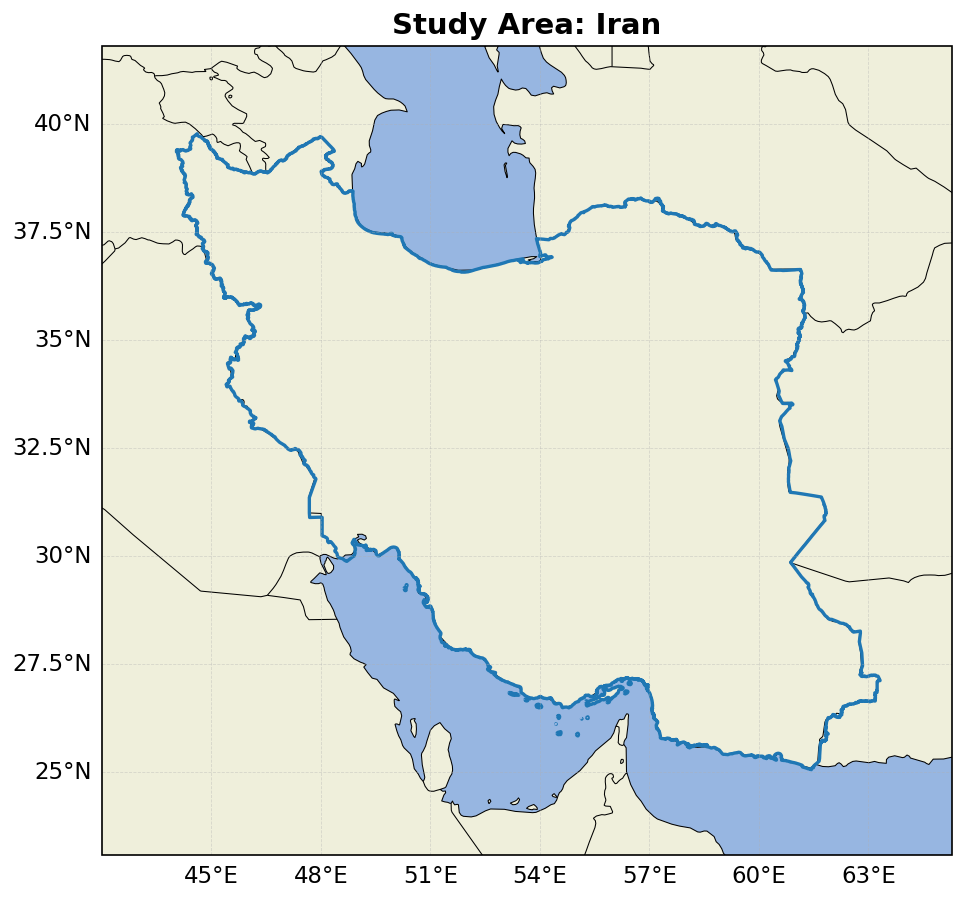

In [45]:
# ============================================================
# Publication-quality study area map using Cartopy
# ============================================================

def plot_study_area_map_cartopy(
    boundary_gdf: gpd.GeoDataFrame,
    ds: xr.Dataset,
    output_dir: Path = MAP_DIR,
    filename: str = "Figure_01_study_area_map_cartopy"
) -> None:
    """
    Plot a publication-quality study area map using Cartopy.

    Parameters
    ----------
    boundary_gdf : geopandas.GeoDataFrame
        Iran boundary GeoDataFrame.
    ds : xr.Dataset
        Iran-clipped snow dataset.
    output_dir : pathlib.Path
        Output directory for the map.
    filename : str
        Output file name without extension.

    Returns
    -------
    None
    """
    if not HAS_CARTOPY:
        print("Cartopy is not installed. Skipping Cartopy-based map.")
        return

    projection = ccrs.PlateCarree()

    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=projection)

    lon_min = float(ds.lon.min().values)
    lon_max = float(ds.lon.max().values)
    lat_min = float(ds.lat.min().values)
    lat_max = float(ds.lat.max().values)

    ax.set_extent(
        [lon_min - 2, lon_max + 2, lat_min - 2, lat_max + 2],
        crs=projection
    )

    ax.add_feature(cfeature.LAND, linewidth=0.3)
    ax.add_feature(cfeature.OCEAN, linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    boundary_gdf.boundary.plot(
        ax=ax,
        transform=projection,
        linewidth=1.6,
        label="Iran boundary"
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        alpha=0.4,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(
        "Study Area: Iran",
        fontsize=14,
        fontweight="bold"
    )

    save_figure(
        fig,
        filename=filename,
        output_dir=output_dir,
        formats=FIGURE_FORMATS
    )

    plt.show()


plot_study_area_map_cartopy(
    iran_gdf,
    ds_iran,
    output_dir=MAP_DIR,
    filename="Figure_01_study_area_map_cartopy"
)